# Drive financial equations from design

The source Model remains immutable. Separate steps author inputs, declare equations, select solve roles, execute, and report accepted output. All currency amounts are AUD. Each floor and utility contributes once, even if it has shared membership.

In [1]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import display, IFrame
from rangekeeper.examples import design
from rangekeeper.model import Model
from rangekeeper.graph import View, Hierarchy
from rangekeeper.graph.projection import to_table, FieldColumn, ValueColumn, PropertyColumn
from rangekeeper.adapters import cytoscape
from rangekeeper.adapters.plotting import plot_flows, plot_partition
from rangekeeper.io import json as codec

MODE = os.environ.get("RK_DESIGN_MODE", "fixture")
print("Declared design mode:", MODE)
OUTPUT = Path("design-output")
OUTPUT.mkdir(exist_ok=True)


Declared design mode: fixture


## Receive or load

Historical Speckle content requires an explicit reviewed mapping. A canonical envelope can instead use `decode_model`. Collection nesting does not establish domain membership.

In [2]:
if MODE == "fixture":
    source = design.fixture()
    utility_names = {"cores": "cores"}
elif MODE == "live":
    from specklepy.api.client import SpeckleClient
    from rangekeeper.adapters.speckle import receive
    from rangekeeper.migration.speckle import MappingSpec, convert_speckle
    client = SpeckleClient(host="app.speckle.systems")
    client.authenticate_with_token(os.environ["SPECKLE_TOKEN"])
    received = receive(client, project_id="c0f66c35e3", object_id="e7acaac21ae7e9369339900a4aaeb827")
    mapping = MappingSpec(
        classifications=("floor", "space", "utilities", "building", "property"),
        relationships=("spatiallyContains", "services", "contains"),
        measurements={"gfa": "meter ** 2", "volume": "meter ** 3", "ffl": "meter", "ftf": "meter", "perimeter": "meter"},
        properties=("use", "number"),
        source_name="Speckle c0f66c35e3/e7acaac21ae7e9369339900a4aaeb827",
    )
    conversion = convert_speckle(received.payload, mapping=mapping)
    assert conversion.model is not None, conversion.issues
    source = conversion.model
    utility_names = {"buildingAcores": "cores", "buildingBcores": "cores", "plinthplant": "plant"}
elif MODE == "canonical":
    from rangekeeper.adapters.speckle import decode_model
    import json
    source = decode_model(json.loads(Path(os.environ["RK_DESIGN_ENVELOPE"]).read_text()))
    utility_names = json.loads(Path(os.environ["RK_DESIGN_INTERPRETATION"]).read_text())["utility_names"]
else:
    raise ValueError("Select fixture, live, or canonical explicitly")
source = Model.from_data(source.to_data())
print("Model revision:", source.id, "Objects:", len(source.find_entities()))


Model revision: bce1e752-588a-4c52-a22a-43d4f87cfc9b Objects: 4


## Select by identity

Classification codes are resolved once to UUIDs. Names remain search labels. Spatial containment is selected separately from services and other relationships. This tree projection checks for multiple parents; the ordinary graph viewer also supports shared membership.

In [3]:
spatial = design.classification_id(source, "spatiallyContains")
spatial_view = View(source, relationships=[e.id for e in source.system.relationships if e.classification == spatial])
hierarchy = Hierarchy(spatial_view)
root = hierarchy.root
contributors = design.select_contributors(source, root=root)
table = to_table(spatial_view, columns=(
    FieldColumn("ID", "entity_id"), FieldColumn("Name", "name"),
    FieldColumn("Class", "classification_code"), ValueColumn("GFA (m²)", "gfa", "meter ** 2"),
    PropertyColumn("Use", "use"), PropertyColumn("Number", "number"),
))
display(pd.DataFrame([dict(row.values) for row in table.rows]))
viewer = cytoscape.write_viewer([cytoscape.project(spatial_view, "Spatial containment")], OUTPUT / "spatial.html")
display(IFrame(src=str(viewer), width="100%", height=600))


,ID,Name,Class,GFA (m²),Use,Number
0,68bb7529-541f-5dc4-9742-57398a8cacff,floor,floor,1000.0,None,1.0
1,e98fc2e9-a2f2-560f-a4c4-140d695b0e85,cores,utilities,NaN,cores,NaN
2,26987824-5607-5f51-88e0-fc041bb02609,space,space,NaN,hotel,NaN
3,3912b85d-46e4-5e98-af3f-593bca6886b5,property,property,NaN,None,NaN


## Report detached data

Areas below use unique floor identities. Parent totals are calculated for presentation and are not added to their constituents.

In [4]:
from rangekeeper.model.characteristics import value as local_value
from rangekeeper.units import default_units
areas = {}
for uid in contributors:
    item = local_value(source.entity(uid).characteristics, "gfa")
    if item is not None:
        assert item.quantity is not None, f"Unresolved GFA: {uid}"
        areas[uid] = default_units.convert(item.quantity, to="meter ** 2").magnitude
for chart in ("sunburst", "treemap"):
    figure = plot_partition(hierarchy, areas, units="m²", title="Gross floor area", kind=chart)
    figure.write_html(OUTPUT / f"gfa-{chart}.html", include_plotlyjs=True)
    display(figure)


## Author the reviewed assumptions

The original hotel, retail, residential and parking assumptions are retained. Utility names are used only for this explicit authoring lookup; the resulting mapping is keyed by UUID. Missing or ambiguous names fail.

In [5]:
utility_kinds = {}
for name, kind in utility_names.items():
    matches = source.find_entities(name=name)
    assert len(matches) == 1, f"Expected one utility named {name}"
    utility_kinds[matches[0].id] = kind
model = design.author(source, root=root, utility_kinds=utility_kinds)
display(pd.DataFrame({"Efficiency": design.EFFICIENCY, "Initial rent (AUD/m²)": design.RENT, "PGI growth": design.GROWTH, "Vacancy": design.VACANCY, "Floor OPEX (AUD/m²)": design.FLOOR_OPEX, "Facade OPEX (AUD/m²)": design.FACADE_OPEX, "Floor CAPEX (AUD/m²)": design.FLOOR_CAPEX}))

,Efficiency,Initial rent (AUD/m²),PGI growth,Vacancy,Floor OPEX (AUD/m²),Facade OPEX (AUD/m²),Floor CAPEX (AUD/m²)
hotel,0.800,750,0.035,0.025,-175,-50,-100
retail,0.675,1000,0.075,0.075,-225,-100,-150
residential,0.750,600,0.055,0.015,-125,-50,-75
parking,0.900,0,0.000,0.000,-65,-25,-50


## Declare governing mathematics

Facade area is perimeter × floor-to-floor height. PGI, vacancy, EGI, floor and facade OPEX, floor and utility CAPEX, NOI and NACF each have explicit equations.

The eleven-year calculation span starts in 2001. Five-year capital payments occur at the ends of 2005 and 2010. Their growth exponents are 0 and 1: 3.5% **per five-year interval**. The extra 2011 NACF supplies reversion at 5%, received at the end of 2010. This preserves the original NACF basis. Ten investment cashflows are discounted by 7%, starting at exponent 1.

In [6]:
model = design.formulate(model)
from rangekeeper.specification import Specification
# The full design has thousands of expanded symbols. Make its budget explicit.
time_limit = float(os.environ.get("RK_DESIGN_TIME_LIMIT", "30" if MODE == "fixture" else "300"))
specification = Specification.from_data({
    **design.specify(model).to_data(), "settings": {"time_limit": time_limit},
})
print("Declared execution time limit (seconds):", time_limit)
print("Explicit unknowns:", len(specification.record.unknowns))

Declared execution time limit (seconds): 30.0
Explicit unknowns: 395


## Execute and accept

The same Pyomo/HiGHS executor used by the scalar and temporal examples solves these affine equations. Its independent evaluator checks the original expressions before output publication. Storage is explicit and local to this notebook.

In [7]:
from rangekeeper.io.memory import MemoryStore
from rangekeeper.execution import Executor
store = MemoryStore()
store.put(model)
run = Executor(store).execute(specification)
assert run.report.status.solution == "feasible", run.report
accepted = store.load_model(run.record.outputs[0])
results = design.values(accepted)
codec.write(accepted, OUTPUT / "accepted-model.json")
print("Accepted Run:", run.id)
print(f"Property PV: AUD {results['pv'].quantity.magnitude:,.2f}")

Accepted Run: ffc1a95d-ff6c-4564-886c-5dfad0605772
Property PV: AUD 8,664,230.65


## Report component and aggregate cashflows

Expenses retain their negative sign. Zero in the non-payment years is a declared zero, not missing data. Source evidence and prior Claims remain available in the accepted Model.

/var/folders/sk/cjq5zjks7gx_3tf9m67y43xr0000gn/T/ipykernel_63643/1061869740.py:3: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,pgi,vacancy,egi,floor_opex,facade_opex,opex,floor_capex,utility_capex,capex,noi,nacf,reversion,total,discounted
2001-12-31,600000.000000,-15000.000000,585000.000000,-175000.000000,-18000.000000,-193000.000000,-0.0,-0.0,-0.0,392000.000000,392000.000000,-0.0,392000.0,366355.140187
2002-12-31,621000.000000,-15525.000000,605475.000000,-181125.000000,-18630.000000,-199755.000000,-0.0,-0.0,-0.0,405720.000000,405720.000000,-0.0,405720.0,354371.560835
2003-12-31,642735.000000,-16068.375000,626666.625000,-187464.375000,-19282.050000,-206746.425000,-0.0,-0.0,-0.0,419920.200000,419920.200000,-0.0,419920.2,342779.967724
2004-12-31,665230.725000,-16630.768125,648599.956875,-194025.628125,-19956.921750,-213982.549875,-0.0,-0.0,-0.0,434617.407000,434617.407000,-0.0,434617.407,331567.538873
2005-12-31,688513.800375,-17212.845009,671300.955366,-200816.525109,-20655.414011,-221471.939121,-100000.0,-2000.0,-102000.0,449829.016245,347829.016245,-0.0,347829.016245,247997.281406
2006-12-31,712611.783388,-17815.294585,694796.488803,-207845.103488,-21378.353502,-229223.456990,-0.0,-0.0,-0.0,465573.031814,465573.031814,-0.0,465573.031814,310230.969368
2007-12-31,737553.195807,-18438.829895,719114.365912,-215119.682110,-22126.595874,-237246.277984,-0.0,-0.0,-0.0,481868.087927,481868.087927,-0.0,481868.087927,300083.227379
2008-12-31,763367.557660,-19084.188941,744283.368718,-222648.870984,-22901.026730,-245549.897714,-0.0,-0.0,-0.0,498733.471004,498733.471004,-0.0,498733.471004,290267.420876
2009-12-31,790085.422178,-19752.135554,770333.286624,-230441.581469,-23702.562665,-254144.144134,-0.0,-0.0,-0.0,516189.142490,516189.142490,-0.0,516189.14249,280772.692156
2010-12-31,817738.411954,-20443.460299,797294.951655,-238507.036820,-24532.152359,-263039.189179,-103500.0,-2070.0,-105570.0,534255.762477,428685.762477,11059094.28327,11487780.045746,5839804.854455


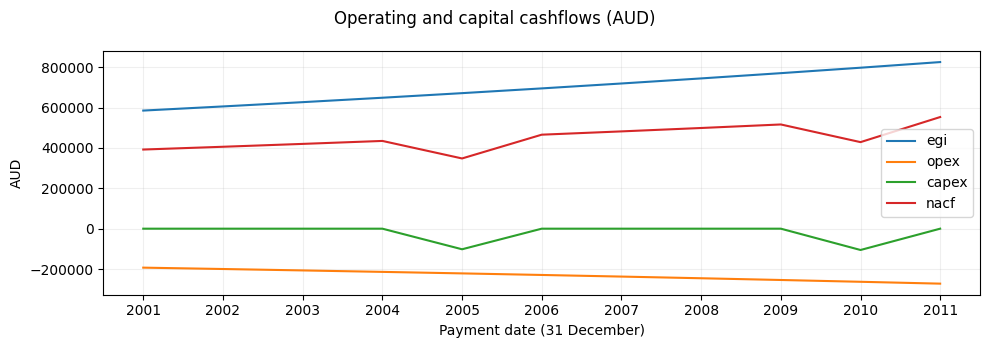

Average annual OPEX (11-period calculation span): -230582.2218905772
Average annual CAPEX (11-period calculation span): -18870.0


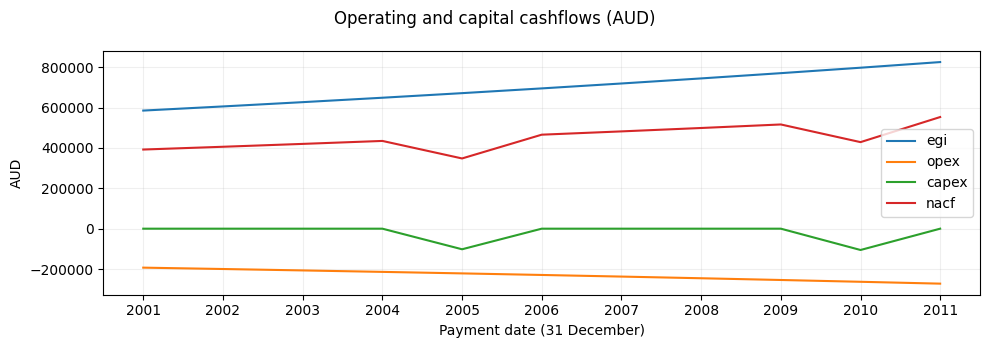

In [8]:
from rangekeeper.adapters.pandas import to_series
component_names = ("pgi", "vacancy", "egi", "floor_opex", "facade_opex", "opex", "floor_capex", "utility_capex", "capex", "noi", "nacf", "reversion", "total", "discounted")
display(pd.DataFrame({name: to_series(results[name].flow) for name in component_names}).fillna("outside declared horizon"))
figure = plot_flows({name: results[name].flow for name in ("egi", "opex", "capex", "nacf")}, title="Operating and capital cashflows (AUD)")
# Label the actual year-end payment dates, rather than the next January tick.
axis = figure.axes[0]
axis.set_xticks([movement.date for movement in results["nacf"].flow.movements])
axis.set_xticklabels([str(movement.date.year) for movement in results["nacf"].flow.movements])
axis.set_xlabel("Payment date (31 December)")
figure.tight_layout()
figure.savefig(OUTPUT / "components.png", dpi=150)
display(figure)
print("Average annual OPEX (11-period calculation span):", to_series(results["opex"].flow).mean())
print("Average annual CAPEX (11-period calculation span):", to_series(results["capex"].flow).mean())

## Inspect contributions

Each chart sums direct contributor amounts over the eleven-period calculation span. Expense charts explicitly display magnitudes for positive-area rendering; the Model keeps signed expenses.

In [9]:
for key in ("egi", "opex", "capex"):
    amounts = {uid: sum(m.magnitude for m in design.values(accepted, uid)[key].flow.movements) for uid in contributors}
    for chart in ("sunburst", "treemap"):
        figure = plot_partition(hierarchy, amounts, units="AUD", title=key.upper()+" contributions", kind=chart, expense_magnitudes=key in ("opex", "capex"))
        figure.write_html(OUTPUT / f"{key}-{chart}.html", include_plotlyjs=True)
        display(figure)